In [2]:
#import statements
import pandas as pd
import sqlite3

In [3]:
#loading the dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [4]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [5]:
df.shape

(1470, 35)

In [6]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [7]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [8]:
#checking for missing values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Data Cleaning

In [9]:
print(df.duplicated().sum())

0


In [10]:
#dropping only one-valued columns in the dataset
df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'])

In [11]:
#converting Attrition column values from Y/N to 0/1
df['Attrition_values']=df['Attrition'].apply(lambda x:1 if x=='Yes' else 0)

In [12]:
df.shape

(1470, 33)

### Loading data into SQLite Database

In [13]:
# Creating a database file
conn = sqlite3.connect("hr_attrition.db")

In [14]:
# Saving the dataframe as a SQL table
df.to_sql("employees", conn, if_exists="replace", index=False)
print("Data loaded into database")

Data loaded into database


In [15]:
def query(sql):
    return pd.read_sql_query(sql, conn)

In [16]:
# Overall attrition rate
query("""
    SELECT 
        ROUND(SUM(Attrition_values)*100.0/COUNT(*),2) AS attrition_rate
    FROM employees
""")

,attrition_rate
0,16.12


In [17]:
# Attrition by Department
query("""
    SELECT 
      Department,
      ROUND(SUM(Attrition_values)*100.0/COUNT(*),2) AS attrition_rate
      FROM employees
      GROUP BY Department
      ORDER BY attrition_rate DESC
      """)

,Department,attrition_rate
0,Sales,20.63
1,Human Resources,19.05
2,Research & Development,13.84


In [ ]:
# Attrition by age group
query("""
    SELECT 
      CASE WHEN
      Age<30 THEN 'Under 30'
      WHEN Age BETWEEN 30 AND 40 THEN '30-40'
      ELSE 'ABOVE 40'
      END 
      AS age_group,
      ROUND(SUM(Attrition_values)*100.0/COUNT(*),2) AS attrition_rate
      FROM employees
      GROUP BY age_group
      ORDER BY attrition_rate DESC
"""
)

,age_group,attrition_rate
0,Under 30,27.91
1,30-40,13.84
2,ABOVE 40,11.18


In [19]:
# Attrition by Job Role
query("""
    SELECT
      JobRole,
      ROUND(SUM(Attrition_values)*100.0/COUNT(*),2) AS attrition_rate
      FROM employees
      GROUP BY JobRole
      ORDER BY attrition_rate DESC

"""

)

,JobRole,attrition_rate
0,Sales Representative,39.76
1,Laboratory Technician,23.94
2,Human Resources,23.08
3,Sales Executive,17.48
4,Research Scientist,16.10
5,Manufacturing Director,6.90
6,Healthcare Representative,6.87
7,Manager,4.90
8,Research Director,2.50


In [23]:
# Attrition by salary range
query("""
    SELECT
      CASE 
      WHEN MonthlyIncome<3000 THEN 'Low (<4k)'
      WHEN MonthlyIncome BETWEEN 4000 AND 9000 THEN 'Mid (4k-9k)'
      ELSE 'High (>9k)'
      END
      AS salary_band,
      ROUND(SUM(Attrition_values)*100.0/COUNT(*),2) AS attrition_rate
      FROM employees
      GROUP BY salary_band
      ORDER BY attrition_rate DESC
      
      """)

,salary_band,attrition_rate
0,Low (<4k),28.61
1,High (>9k),12.08
2,Mid (4k-9k),11.09


### EDA

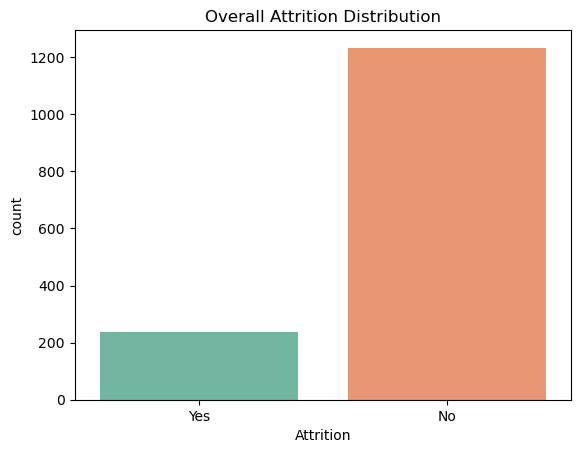

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Attrition count
sns.countplot(data=df, x='Attrition', palette='Set2')
plt.title('Overall Attrition Distribution')
plt.savefig('attrition_count.png')
plt.show()



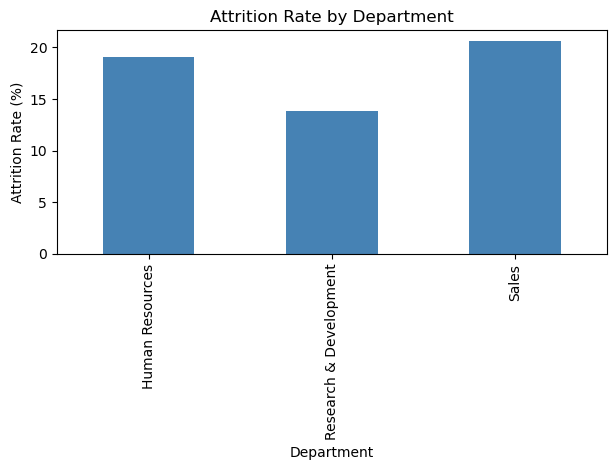

In [26]:
# Attrition by Department
dept = df.groupby('Department')['Attrition_values'].mean() * 100
dept.plot(kind='bar', color='steelblue', title='Attrition Rate by Department')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('dept_attrition.png')
plt.show()


c:\Users\LENOVO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


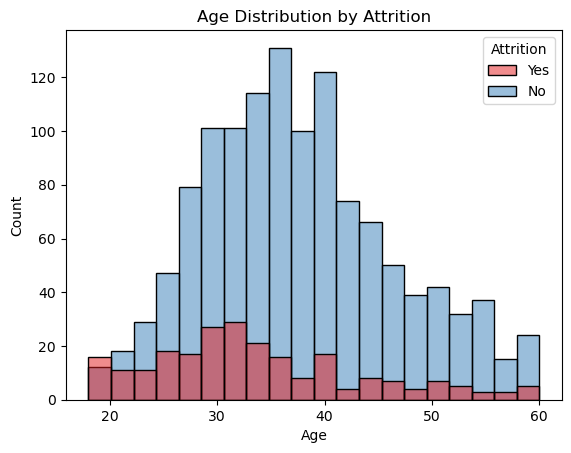

In [27]:
# Age distribution for attrition vs non-attrition
sns.histplot(data=df, x='Age', hue='Attrition', bins=20, palette='Set1')
plt.title('Age Distribution by Attrition')
plt.savefig('age_attrition.png')
plt.show()


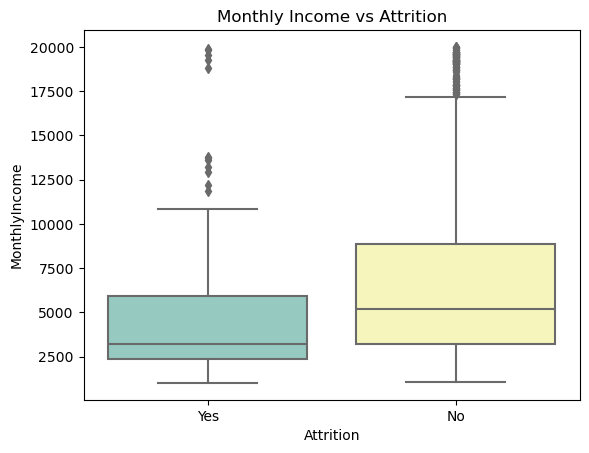

In [28]:

# Monthly Income vs Attrition
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set3')
plt.title('Monthly Income vs Attrition')
plt.savefig('income_attrition.png')
plt.show()